In [1]:
"""
Plotting results from the ying-yang dataset analysis
"""

import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import argparse
import csv
import fcntl
import jax
import math
import jax.numpy as jnp
import optax
import flax
from flax import nnx
from flax.nnx.nn import initializers
from typing import Callable
import json
import glob

import pickle
import numpy as np
from collections import defaultdict
from functools import partial
from tqdm import tqdm
from datetime import date

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
import cmap



from utils import ternary_activation, load_cifar10_augment, dual_sample_ternary, load_uci_iris
from models import TernaryStochasticActivation, DualSampleTernary, CustomLinear, FFN 

import tensorflow_datasets as tfds  # TFDS to download CIFAR-10.
import tensorflow as tf  # TensorFlow / `tf.data` operations.
tf.config.set_visible_devices([], 'GPU')

today = date.today().isoformat()

# set the flag for stayem
system_flag = "macbook" # or mahowald

# Path for loading the models: UPDATE BASED ON MACHINE
if system_flag == "mahowald":
    MODEL_PATH = "/local_disk/vikrant/trident/models"
    FIGURES_PATH = "../plots/"
    DATA_PATH = "/local_disk/vikrant/trident/logs"

elif system_flag == "macbook":
    # set latex backend for matplotlib
    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'
    
    DATA_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs"
    MODEL_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/models"
    FIGURES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels"
    SLIDES_PATH = "/Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/presentation_figures"


else:
    raise ValueError("Invalid system flag. Please set it to either 'mahowald' or 'macbook'.")

print("*** PATHS ARE SET AS ***")
print(f"Model path: {MODEL_PATH}")
print(f"Data path: {DATA_PATH}")
print(f"Figures path: {FIGURES_PATH}")

*** PATHS ARE SET AS ***
Model path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/models
Data path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/logs
Figures path: /Users/vikrantjaltare/OneDrive - UC San Diego/trident/figures/plot_panels


In [2]:
# Load the data: nu-hl sweep
yy_nu_hl_sweep = pickle.load(open(os.path.join(DATA_PATH, "yin_yang_nu_hl_sweep_noise_gaussian_2026-08-31.pkl"), "rb"))

yy_nu_hl_data = yy_nu_hl_sweep["data"]
yy_nu_hl_configs = yy_nu_hl_sweep["configs"]

print(f"CONFIGS \n {yy_nu_hl_configs}")

# convert the data to pandas
yy_nu_dl_df = pd.DataFrame(yy_nu_hl_data)
print(yy_nu_dl_df.head())

CONFIGS 
 {'n_hl_sweep': [1, 2, 3, 4, 5], 'nu_sweep': [2, 20, 200, 2000], 'seed': 0, 'batch_size': 64, 'resamples': 5, 'hidden_layer_size': 200, 'adamw_used': True, 'noise_dist': 'gaussian', 'noise_std': 1.0, 'noise_mean': 0.0, 'learning_rate': 0.0005, 'train_steps': 30000, 'n_train': 8000, 'n_test': 2000}
   nu  n_hl  resample  best_train_accuracy  best_test_accuracy
0   2     1         0             0.703125              0.7180
1   2     1         1             0.726326              0.7295
2   2     1         2             0.700156              0.7125
3   2     1         3             0.715469              0.7280
4   2     1         4             0.720781              0.7220


In [ ]:
# load the data: hl_size, nu sweep
yy_hl_size = pickle.load(open(os.path.join(DATA_PATH, "yin_yang_hl_size_nu_sweep_noise_gaussian_2026-09-07.pkl"), "rb"))

yy_hl_size_data = pd.DataFrame(yy_hl_size['data'])
yy_hl_size_configs = yy_hl_size['configs']

print(f"CONFIGS: {yy_hl_size_configs}")
print(yy_hl_size_data.head())

# load the single 10000 layer case for nu=2
# TODO

CONFIGS: {'num_hidden_layers': 3, 'hl_size_sweep': [10, 100, 1000, 5000], 'nu_sweep': [2, 20, 200], 'seed': 0, 'batch_size': 64, 'resamples': 5, 'adamw_used': True, 'noise_dist': 'gaussian', 'noise_std': 1.0, 'noise_mean': 0.0, 'learning_rate': 0.0005, 'train_steps': 30000, 'n_train': 8000, 'n_test': 2000}
   hidden_layer_size   nu  resample  best_train_accuracy  best_test_accuracy
0               5000  200         0             0.958906               0.973
1               5000  200         1             0.966250               0.980
2               5000  200         2             0.968281               0.976
3               5000  200         3             0.969375               0.978
4               5000  200         4             0.968437               0.975


/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_49436/715020071.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(data=yy_hl_size_data, x="hidden_layer_size", y="best_test_accuracy", hue="nu", palette=cb_pal, lw=2, alpha=0.5, err_style="bars", err_kws={"capsize": 5})


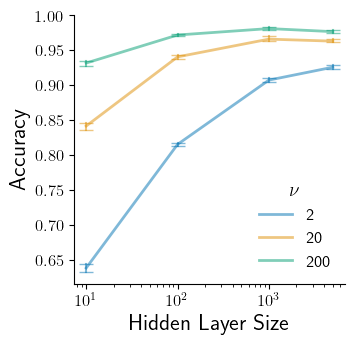

In [19]:
cb_pal = sns.color_palette("colorblind")
fig, ax = plt.subplots(figsize=(3.5, 3.5))

sns.lineplot(data=yy_hl_size_data, x="hidden_layer_size", y="best_test_accuracy", hue="nu", palette=cb_pal, lw=2, alpha=0.5, err_style="bars", err_kws={"capsize": 5})

ax.set_xscale("log", base=10)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel("Hidden Layer Size", fontsize=16)
ax.set_ylabel("Accuracy", fontsize=16)

# ax.plot([2], [0], color="k", marker="o")

ax.legend(frameon=False, title_fontsize=14, fontsize=12, title=r"$\nu$")

sns.despine()

<>:6: SyntaxWarning: invalid escape sequence '\#'
<>:20: SyntaxWarning: invalid escape sequence '\#'
<>:6: SyntaxWarning: invalid escape sequence '\#'
<>:20: SyntaxWarning: invalid escape sequence '\#'
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_42538/1262580280.py:6: SyntaxWarning: invalid escape sequence '\#'
  ax[0].set_xlabel("\# Hidden Layers", fontsize=16)
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_42538/1262580280.py:20: SyntaxWarning: invalid escape sequence '\#'
  ax[1].legend(title="\# Hidden\nLayers", fontsize=13, title_fontsize=14, frameon=False, loc=(1, 0.3))
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ipykernel_42538/1262580280.py:4: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.lineplot(data=yy_nu_dl_df, x="n_hl", y="best_test_accuracy", hue="nu", palette=cb_pal, ax=ax[0], lw=2, alpha=0.5, err_style="bars", err_kws={"capsize": 5})
/var/folders/ll/h6rw2gtd69710246lczqf90c0000gn/T/ip

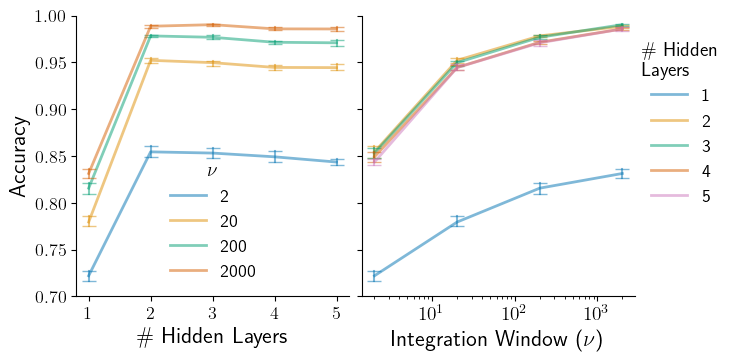

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(7.25, 3.5), layout="constrained", sharey=True)

cb_pal = sns.color_palette("colorblind")
sns.lineplot(data=yy_nu_dl_df, x="n_hl", y="best_test_accuracy", hue="nu", palette=cb_pal, ax=ax[0], lw=2, alpha=0.5, err_style="bars", err_kws={"capsize": 5})
# sns.lineplot(data=yy_nu_dl_df, x="n_hl", y="best_train_accuracy", hue="nu", palette=cb_pal, ax=ax[0], lw=2, alpha=0.5, err_style="bars", ls="--", legend=False, err_kws={"capsize": 5})
ax[0].set_xlabel("\# Hidden Layers", fontsize=16)
ax[0].set_ylabel("Accuracy", fontsize=16)
ax[0].tick_params(axis='both', which='major', labelsize=13)

ax[0].legend(title=r"$\nu$", fontsize=13, title_fontsize=14, frameon=False)

# right plot: nu vs accuracy for different n_hl
sns.lineplot(data=yy_nu_dl_df, x="nu", y="best_test_accuracy", hue="n_hl", palette=cb_pal, ax=ax[1], lw=2, alpha=0.5, err_style="bars", err_kws={"capsize": 5})
# sns.lineplot(data=yy_nu_dl_df, x="nu", y="best_train_accuracy", hue="n_hl", palette=cb_pal, ax=ax[1], lw=2, alpha=0.5, err_style="bars", ls="--", legend=False, err_kws={"capsize": 5})
ax[1].set_xlabel(r"Integration Window ($\nu$)", fontsize=16)
ax[1].set_ylabel("Accuracy", fontsize=16)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[1].set_xscale("log", base=10)

ax[1].legend(title="\# Hidden\nLayers", fontsize=13, title_fontsize=14, frameon=False, loc=(1, 0.3))

# create an inset axis
# ax_inset = ax.inset_axes([0.3, 0.1, 0.33, 0.33])  # [x0, y0, width, height]
# sns.lineplot(data=yy_nu_dl_df, x="nu", y="best_test_accuracy", hue="n_hl", palette=cb_pal, ax=ax_inset, lw=2, alpha=0.5, err_style="bars", err_kws={"capsize": 5})
for axs in [ax[0], ax[1]]:
    axs.set_ylim(0.7, 1.0)

sns.despine()
# fig_name = os.path.join(FIGURES_PATH, f"ying_yanh_nu_hl_sweep_{today}.pdf")
# fig.savefig(fig_name, bbox_inches="tight", transparent=True, dpi=300)

In [21]:
# accuracies for nu>1000
df_nu3 = yy_nu_dl_df.loc[yy_nu_dl_df["nu"] > 1000].loc[yy_nu_dl_df['n_hl'] > 1]
m_nu3 = df_nu3['best_test_accuracy'].mean()
se_nu3 = df_nu3['best_test_accuracy'].std()
se_nu3 = se_nu3/jnp.sqrt(len(df_nu3)) * 1.96

print(m_nu3, se_nu3)

0.9876000463962555 0.0011521124


In [14]:
# preactivation distributions || Hidden Layer Size = 200
yy_preact_n2 = pickle.load(open(os.path.join(DATA_PATH, "yin_yang_preactivations_nhl_200_nu_2_noise_gaussian_2026-09-02.pkl"), "rb"))
yy_preact_n2_configs = yy_preact_n2["configs"]
yy_preact_n2_data = yy_preact_n2["data"]

print(f"CONFIGS \n {yy_preact_n2_configs}")
yy_preact_n2_df = pd.DataFrame(yy_preact_n2_data)
yy_preact_n2_df.head()

yy_preact_n200 = pickle.load(open(os.path.join(DATA_PATH, "yin_yang_preactivations_nhl_200_nu_200_noise_gaussian_2026-09-02.pkl"), "rb"))
yy_preact_n200_configs = yy_preact_n200["configs"]
yy_preact_n200_data = yy_preact_n200["data"]

print(f"CONFIGS \n {yy_preact_n200_configs}")
yy_preact_n200_df = pd.DataFrame(yy_preact_n200_data)
yy_preact_n200_df.head()

CONFIGS 
 {'seed': 0, 'layer_sizes': [2, 200, 200, 200, 3], 'num_hidden_layers': 3, 'hidden_layer_size': 200, 'nu': 2, 'noise_std': 1.0, 'noise_mean': 0.0, 'noise_dist': 'gaussian', 'train_accuracy': 0.8479687571525574, 'test_accuract': 0.8575000166893005, 'data_split': 'both', 'n_points': 10000}
CONFIGS 
 {'seed': 0, 'layer_sizes': [2, 200, 200, 200, 3], 'num_hidden_layers': 3, 'hidden_layer_size': 200, 'nu': 200, 'noise_std': 1.0, 'noise_mean': 0.0, 'noise_dist': 'gaussian', 'train_accuracy': 0.9706249833106995, 'test_accuract': 0.9740000367164612, 'data_split': 'both', 'n_points': 10000}


,hl1,hl2,hl3
0,0.291150,1.275502,-7.194581
1,-0.400963,-1.885285,-1.961055
2,-0.072394,0.507666,-10.484571
3,-0.680986,-6.991698,0.002823
4,-0.657367,-0.922623,-0.929805


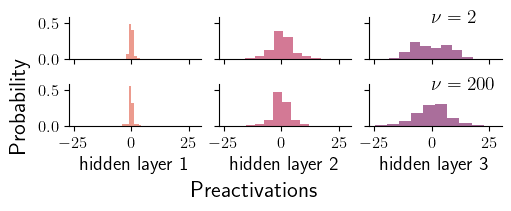

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(5, 2), layout="constrained", sharex=True, sharey=True)

flare_pal = sns.color_palette("flare", n_colors=3)
crest_pal = sns.color_palette("crest", n_colors=3)

stat_str = "probability"

# top three: layerwise distributions for nu=2
sns.histplot(data=yy_preact_n2_df, x="hl1", ax=ax[0,0], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[0], lw=0, edgecolor=None)
sns.histplot(data=yy_preact_n2_df, x="hl2", ax=ax[0,1], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[1], lw=0, edgecolor=None)
sns.histplot(data=yy_preact_n2_df, x="hl3", ax=ax[0,2], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[2], lw=0, edgecolor=None)
ax[0, 0].set_ylabel("")

# bottom three: layerwise distributions for nu=200
sns.histplot(data=yy_preact_n200_df, x="hl1", ax=ax[1,0], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[0], lw=0, edgecolor=None)
sns.histplot(data=yy_preact_n200_df, x="hl2", ax=ax[1,1], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[1], lw=0, edgecolor=None)
sns.histplot(data=yy_preact_n200_df, x="hl3", ax=ax[1,2], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[2], lw=0, edgecolor=None)
ax[1, 0].set_ylabel("")

for axs in ax.ravel():
    axs.set_ylabel("")
    axs.set_xlabel("")
    axs.tick_params(axis='both', which='major', labelsize=12)

for i, axs in enumerate(ax[1, ...]):
    axs.set_xlabel(f"hidden layer {i+1}", fontsize=14)

ax[0, 2].text(0, 0.5, r"$\nu=2$", fontsize=14)
ax[1, 2].text(0, 0.5, r"$\nu=200$", fontsize=14)

# add sup ylabel
fig.supylabel("Probability", fontsize=16)
fig.supxlabel("Preactivations", fontsize=16)

sns.despine()

# fig_name = os.path.join(FIGURES_PATH, f"ying_yanh_preactivations_nu_2_200_{today}.pdf")
# fig.savefig(fig_name, bbox_inches="tight", transparent=True, dpi=300)

In [16]:
# preactivation distributions || Hidden Layer Size = 10
yy_preact_n2_nhl2 = pickle.load(open(os.path.join(DATA_PATH, "yin_yang_preactivations_nhl_10_nu_2_noise_gaussian_2026-09-02.pkl"), "rb"))
yy_preact_n2_nhl2_configs = yy_preact_n2_nhl2["configs"]
yy_preact_n2_nhl2_data = yy_preact_n2_nhl2["data"]

print(f"CONFIGS \n {yy_preact_n2_nhl2_configs}")
yy_preact_n2_nhl2_df = pd.DataFrame(yy_preact_n2_nhl2_data)
yy_preact_n2_nhl2_df.head()

yy_preact_n200_nhl2 = pickle.load(open(os.path.join(DATA_PATH, "yin_yang_preactivations_nhl_10_nu_200_noise_gaussian_2026-09-02.pkl"), "rb"))
yy_preact_n200_nhl2_configs = yy_preact_n200_nhl2["configs"]
yy_preact_n200_nhl2_data = yy_preact_n200_nhl2["data"]

print(f"CONFIGS \n {yy_preact_n200_nhl2_configs}")
yy_preact_n200_nhl2_df = pd.DataFrame(yy_preact_n200_nhl2_data)
yy_preact_n200_nhl2_df.head()

CONFIGS 
 {'seed': 0, 'layer_sizes': [2, 10, 10, 10, 3], 'num_hidden_layers': 3, 'hidden_layer_size': 10, 'nu': 2, 'noise_std': 1.0, 'noise_mean': 0.0, 'noise_dist': 'gaussian', 'train_accuracy': 0.6340624690055847, 'data_split': 'both', 'n_points': 10000}
CONFIGS 
 {'seed': 0, 'layer_sizes': [2, 10, 10, 10, 3], 'num_hidden_layers': 3, 'hidden_layer_size': 10, 'nu': 200, 'noise_std': 1.0, 'noise_mean': 0.0, 'noise_dist': 'gaussian', 'train_accuracy': 0.9246875047683716, 'data_split': 'both', 'n_points': 10000}


,hl1,hl2,hl3
0,0.690967,1.710463,-7.740103
1,-0.336636,6.034292,1.421638
2,-0.928918,0.015292,-1.161042
3,-1.281838,-1.007388,-0.782372
4,-0.577037,-2.799483,-1.272705


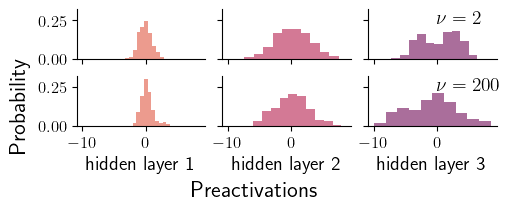

In [ ]:
# preactivation distributions || Hidden Layer Size = 10

fig, ax = plt.subplots(2, 3, figsize=(5, 2), layout="constrained", sharex=True, sharey=True)

flare_pal = sns.color_palette("flare", n_colors=3)
crest_pal = sns.color_palette("crest", n_colors=3)

stat_str = "probability"

# top three: layerwise distributions for nu=2
sns.histplot(data=yy_preact_n2_nhl2_df, x="hl1", ax=ax[0,0], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[0], lw=0, edgecolor=None)
sns.histplot(data=yy_preact_n2_nhl2_df, x="hl2", ax=ax[0,1], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[1], lw=0, edgecolor=None)
sns.histplot(data=yy_preact_n2_nhl2_df, x="hl3", ax=ax[0,2], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[2], lw=0, edgecolor=None)
ax[0, 0].set_ylabel("")

# bottom three: layerwise distributions for nu=200
sns.histplot(data=yy_preact_n200_nhl2_df, x="hl1", ax=ax[1,0], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[0], lw=0, edgecolor=None)
sns.histplot(data=yy_preact_n200_nhl2_df, x="hl2", ax=ax[1,1], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[1], lw=0, edgecolor=None)
sns.histplot(data=yy_preact_n200_nhl2_df, x="hl3", ax=ax[1,2], bins=10, stat=stat_str, alpha=0.7, color=flare_pal[2], lw=0, edgecolor=None)
ax[1, 0].set_ylabel("")

for axs in ax.ravel():
    axs.set_ylabel("")
    axs.set_xlabel("")
    axs.tick_params(axis='both', which='major', labelsize=12)

for i, axs in enumerate(ax[1, ...]):
    axs.set_xlabel(f"hidden layer {i+1}", fontsize=14)

ax[0, 2].text(0, 0.23, r"$\nu=2$", fontsize=14)
ax[1, 2].text(0, 0.23, r"$\nu=200$", fontsize=14)

# add sup ylabel
fig.supylabel("Probability", fontsize=16)
fig.supxlabel("Preactivations", fontsize=16)

sns.despine()
# fig_name = os.path.join(FIGURES_PATH, f"ying_yanh_preactivations_nu_2_200_nhl_10_{today}.pdf")
# fig.savefig(fig_name, bbox_inches="tight", transparent=True, dpi=300)

In [55]:
## plotting decision boundaries across smapling strategies
yy_dec_n2 = pickle.load(open(os.path.join(DATA_PATH, "yin_yang_boundary_noise_gaussian_nu_2_2026-09-01.pkl"), "rb"))
yy_dec_n20 = pickle.load(open(os.path.join(DATA_PATH, "yin_yang_boundary_noise_gaussian_nu_20_2026-09-01.pkl"), "rb"))
yy_dec_n100 = pickle.load(open(os.path.join(DATA_PATH, "yin_yang_boundary_noise_gaussian_nu_100_2026-09-01.pkl"), "rb"))

# for nu=2
yy_dec_n2_configs = yy_dec_n2['configs']
print(f"CONFIGS: {yy_dec_n2}")
yy_dec_n2_df = yy_dec_n2['data']

resolution_n2 = yy_dec_n2_configs['resolution']
xx_n2 = yy_dec_n2_df['xx'].reshape(resolution_n2, resolution_n2)
yy_n2 = yy_dec_n2_df['yy'].reshape(resolution_n2, resolution_n2)
preds_n2 = yy_dec_n2_df['preds'].reshape(resolution_n2, resolution_n2)
x_test_n2 = yy_dec_n2_df['X_test']
y_test_n2 = yy_dec_n2_df['y_test']

# for nu=20
yy_dec_n20_configs = yy_dec_n20['configs']
print(f"CONFIGS: {yy_dec_n20_configs}")
yy_dec_n20_df = yy_dec_n20['data']

resolution_n20 = yy_dec_n20_configs['resolution']
xx_n20 = yy_dec_n20_df['xx'].reshape(resolution_n20, resolution_n20)
yy_n20 = yy_dec_n20_df['yy'].reshape(resolution_n20, resolution_n20)
preds_n20 = yy_dec_n20_df['preds'].reshape(resolution_n20, resolution_n20)
x_test_n20 = yy_dec_n20_df['X_test']
y_test_n20 = yy_dec_n20_df['y_test']

# for nu=100
yy_dec_n100_configs = yy_dec_n100['configs']
print(f"CONFIGS: {yy_dec_n100_configs}")
yy_dec_n100_df = yy_dec_n100['data']

resolution_n100 = yy_dec_n100_configs['resolution']
xx_n100 = yy_dec_n100_df['xx'].reshape(resolution_n100, resolution_n100)
yy_n100 = yy_dec_n100_df['yy'].reshape(resolution_n100, resolution_n100)
preds_n100 = yy_dec_n100_df['preds'].reshape(resolution_n100, resolution_n100)
x_test_n100 = yy_dec_n100_df['X_test']
y_test_n100 = yy_dec_n100_df['y_test']

CONFIGS: {'configs': {'seed': 0, 'layer_sizes': [2, 200, 200, 200, 3], 'num_hidden_layers': 3, 'hidden_layer_size': 200, 'nu': 2, 'noise_std': 1.0, 'noise_mean': 0.0, 'noise_dist': 'gaussian', 'eval_accuracy': 0.8580000400543213, 'resolution': 300}, 'data': {'xx': array([0.        , 0.00334448, 0.00668896, ..., 0.99331104, 0.99665552,
       1.        ], shape=(90000,)), 'yy': array([0., 0., 0., ..., 1., 1., 1.], shape=(90000,)), 'preds': array([0, 0, 0, ..., 1, 1, 1], shape=(90000,), dtype=int32), 'X_test': array([[0.541256  , 0.19623363],
       [0.49036783, 0.1551956 ],
       [0.40791875, 0.4849095 ],
       ...,
       [0.7063169 , 0.5120805 ],
       [0.3039366 , 0.5698879 ],
       [0.08154951, 0.76397836]], shape=(2000, 2), dtype=float32), 'y_test': array([0, 0, 0, ..., 2, 2, 1], shape=(2000,), dtype=int32)}}
CONFIGS: {'seed': 0, 'layer_sizes': [2, 200, 200, 200, 3], 'num_hidden_layers': 3, 'hidden_layer_size': 200, 'nu': 20, 'noise_std': 1.0, 'noise_mean': 0.0, 'noise_dist': '

In [62]:
CLASS_NAMES = ["yin", "yang", "dot"]
CLASS_COLORS = ["#3b3b58", "#f2c14e", "#d1495b"]  # dark / light / accent
# CLASS_COLORS = ["#eebfc5", "#c5eebf", "#bfc5ee"]

def plot_dataset(X, y, ax=None, title="Yin-Yang dataset", s=8):
    import matplotlib.pyplot as plt
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    for c, name, color in zip(range(3), CLASS_NAMES, CLASS_COLORS):
        mask = y == c
        ax.scatter(X[mask, 0], X[mask, 1], s=s, color=color, label=name, edgecolors="none")
    ax.set_aspect("equal")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    # ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    return ax
 

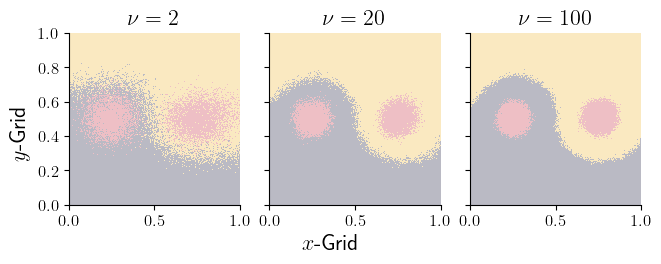

In [ ]:
## plotting three figures: nu=2, 20, 100

fig, ax = plt.subplots(1, 3, figsize=(6.5, 2.5), sharex=True, sharey=True, layout="constrained")

cmap = ListedColormap(CLASS_COLORS)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# left: nu=2
ax[0].pcolormesh(xx_n2, yy_n2, preds_n2, cmap=cmap, norm=norm, shading="auto", alpha=0.35)
ax[0].set_title(r"$\nu=2$", fontsize=16)
ax[0].set_aspect("equal")
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)

# middle: nu=20
ax[1].pcolormesh(xx_n20, yy_n20, preds_n20, cmap=cmap, norm=norm, shading="auto", alpha=0.35)
ax[1].set_title(r"$\nu=20$", fontsize=16)
ax[1].set_aspect("equal")
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, 1)

# right: nu=100
ax[2].pcolormesh(xx_n100, yy_n100, preds_n100, cmap=cmap, norm=norm, shading="auto", alpha=0.35)
ax[2].set_title(r"$\nu=100$", fontsize=16)
ax[2].set_aspect("equal")
ax[2].set_xlim(0, 1)
ax[2].set_ylim(0, 1)

for axs in ax.ravel():
    axs.tick_params(axis="both", labelsize=12, which="major")

fig.supylabel(r"$y$-Grid", fontsize=16)
fig.supxlabel(r"$x$-Grid", fontsize=16)
sns.despine()

# plot_name = os.path.join(FIGURES_PATH, f"yy_decision_boundary_{today}.png")
# fig.savefig(plot_name, transparent=True, dpi=300, bbox_inches="tight")